In [1]:
import torch 
from torch import nn
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch.optim as optim

In [5]:
# load data
data_train = datasets.ImageFolder(root="data/train", transform=transforms.ToTensor())
data_test = datasets.ImageFolder(root="data/test", transform=transforms.ToTensor())
val_data = datasets.ImageFolder(root="data/val", transform=transforms.ToTensor())   

In [6]:
# take look at data
len(data_train), len(data_test), len(val_data)

(5216, 624, 16)

Image shape: torch.Size([3, 1858, 2090]) | Label: 0 | Class name: NORMAL


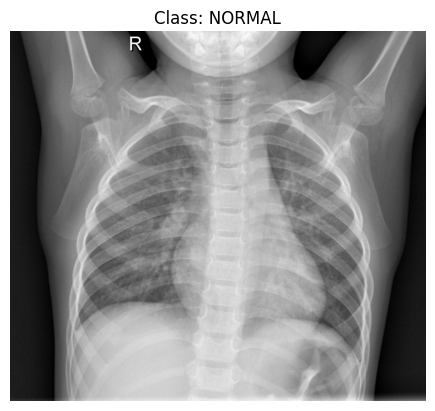

In [11]:
# look at image and label
img, label = data_train[0]
print(f"Image shape: {img.shape} | Label: {label} | Class name: {data_train.classes[label]}")

# lets see the image 
import matplotlib.pyplot as plt
plt.imshow(img.permute(1, 2, 0))
plt.title(f"Class: {data_train.classes[label]}")
plt.axis(False);   

In [10]:
print(data_train.classes)
print(data_train.class_to_idx)

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}


In [12]:
# load 5 images and labels and see there shape and class name
for i in range(5):
    img, label = data_train[i]
    print(f"Image shape: {img.shape} | Label: {label} | Class name: {data_train.classes[label]}")

Image shape: torch.Size([3, 1858, 2090]) | Label: 0 | Class name: NORMAL
Image shape: torch.Size([3, 1152, 1422]) | Label: 0 | Class name: NORMAL
Image shape: torch.Size([3, 1434, 1810]) | Label: 0 | Class name: NORMAL
Image shape: torch.Size([3, 1279, 1618]) | Label: 0 | Class name: NORMAL
Image shape: torch.Size([3, 1125, 1600]) | Label: 0 | Class name: NORMAL


In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [3]:
train_data = datasets.ImageFolder(
    root="data/train",
    transform=train_transform
)

val_data = datasets.ImageFolder(
    root="data/val",
    transform=val_transform
)

test_data = datasets.ImageFolder(
    root="data/test",
    transform=val_transform
)

In [4]:
train_loader = DataLoader(
    train_data,
    batch_size=2,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_data,
    batch_size=2,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_data,
    batch_size=2,
    shuffle=False,
    num_workers=2
)

In [5]:
from torchvision.models import densenet121

model = densenet121(weights="IMAGENET1K_V1")

In [6]:
num_features = model.classifier.in_features

model.classifier = nn.Linear(
    num_features,
    2
)

for param in model.features.parameters():
    param.requires_grad = True

In [7]:
# lets see the model architecture
print(model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=T

In [8]:
# lets train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-5
)

In [9]:
img, label = train_data[0]
print(img.shape)

torch.Size([3, 224, 224])


In [10]:
import torch

# move model to GPU
model = model.to(device)

best_acc = 0.0
epochs = 100

for epoch in range(epochs):

    ####################
    # TRAINING
    ####################
    model.train()

    train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    ####################
    # VALIDATION
    ####################
    model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)

    val_acc = correct / total

    ####################
    # SAVE BEST MODEL
    ####################
    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_densenet122.pth"
        )

        print(
            f"New Best Model Saved! "
            f"Validation Accuracy: {val_acc:.4f}"
        )

    ####################
    # PRINT RESULTS
    ####################
    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

print(f"\nBest Validation Accuracy: {best_acc:.4f}")

New Best Model Saved! Validation Accuracy: 0.7500
Epoch [1/100] | Train Loss: 0.3521 | Val Loss: 0.5052 | Val Acc: 0.7500
Epoch [2/100] | Train Loss: 0.2810 | Val Loss: 0.9352 | Val Acc: 0.6250
New Best Model Saved! Validation Accuracy: 0.8125
Epoch [3/100] | Train Loss: 0.2003 | Val Loss: 0.2903 | Val Acc: 0.8125
Epoch [4/100] | Train Loss: 0.1156 | Val Loss: 0.4054 | Val Acc: 0.7500
Epoch [5/100] | Train Loss: 0.0641 | Val Loss: 0.3721 | Val Acc: 0.7500
New Best Model Saved! Validation Accuracy: 0.9375
Epoch [6/100] | Train Loss: 0.0491 | Val Loss: 0.1708 | Val Acc: 0.9375
Epoch [7/100] | Train Loss: 0.0314 | Val Loss: 0.1454 | Val Acc: 0.8750
Epoch [8/100] | Train Loss: 0.0287 | Val Loss: 0.1244 | Val Acc: 0.9375
Epoch [9/100] | Train Loss: 0.0243 | Val Loss: 0.1359 | Val Acc: 0.9375
Epoch [10/100] | Train Loss: 0.0164 | Val Loss: 0.1490 | Val Acc: 0.9375
Epoch [11/100] | Train Loss: 0.0184 | Val Loss: 0.3769 | Val Acc: 0.8750
Epoch [12/100] | Train Loss: 0.0114 | Val Loss: 0.5834 |

KeyboardInterrupt: 

In [13]:
# load the best model and evaluate on test set
model.load_state_dict(torch.load("best_densenet122.pth"))
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8974


In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(confusion_matrix(y_true, y_pred))

print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_data.classes
    )
)

[[174  60]
 [  4 386]]
              precision    recall  f1-score   support

      NORMAL       0.98      0.74      0.84       234
   PNEUMONIA       0.87      0.99      0.92       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.88       624
weighted avg       0.91      0.90      0.89       624

